In [3]:
# Core
import os, json, math, random, numpy as np, pandas as pd
import sys, importlib
# import text_encoder...

from collections import defaultdict, Counter

# Torch / HF
import torch
from transformers import AutoModel, AutoTokenizer
from tensor2tensor.data_generators import text_encoder
# Clustering & metrics
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score as ARI
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.metrics import homogeneity_completeness_v_measure as HCV
from sklearn.metrics import fowlkes_mallows_score as FMI
from scipy.optimize import linear_sum_assignment

# Viz
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Repro
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed(42)

DEVICE = "cpu"   # keep CPU for evaluation (deterministic & simple)

## Loading data and models

In [4]:
semeval_holdout = pd.read_parquet("../data/wsd_data/semeval_holdout.parquet")
semeval_holdout.sample(10)

,lemma,sense_id,left_context,target_word,right_context,wsd_source,tokens,target_idx,xmlr_wp_span,labert_wp_span,xmlr_wp_len,labert_wp_len,tokens_lemma,target_idx_lemma,xmlr_wp_span_lemma,labert_wp_span_lemma,xmlr_wp_len_lemma,labert_wp_len_lemma
9397,itero,I,non tenebit oportebit autem theriacae infusion...,iterare,est pulchra species uuae quae granis interiori...,semeval_wsd,"[non, tenebit, oportebit, autem, theriacae, in...",10,"[25, 26, 27]","[17, 18]",3,2,"[non, tenebit, oportebit, autem, theriacae, in...",10,"[25, 26]","[17, 18]",2,2
10120,salus,II,tempora rumpit amor duco parum propriam tibi d...,salutem,sed mea prospicio cum tua uota colo nunc cape ...,semeval_wsd,"[tempora, rumpit, amor, duco, parum, propriam,...",10,"[17, 18]",[12],2,1,"[tempora, rumpit, amor, duco, parum, propriam,...",10,"[17, 18]",[12],2,1
9166,honor,IV,tellus et caelum intercipit umbra nullum uer u...,honores,sola iugis habitat diris sedesque tuetur perpe...,semeval_wsd,"[tellus, et, caelum, intercipit, umbra, nullum...",10,"[20, 21]",[14],2,1,"[tellus, et, caelum, intercipit, umbra, nullum...",10,[20],[14],1,1
8723,consilium,I,quod nequeunt augent ex pauxillo de parant mih...,consili,malam rem prius quam ut meum vt adhuc fuit mi,semeval_wsd,"[quod, nequeunt, augent, ex, pauxillo, de, par...",10,"[17, 18]","[14, 15]",2,2,"[quod, nequeunt, augent, ex, pauxillo, de, par...",10,[17],[14],1,1
9427,itero,I,aedes evocem quae audivistis modo nunc si eade...,iterem,inscitiast ero uni potius intus ero odio quam ...,semeval_wsd,"[aedes, evocem, quae, audivistis, modo, nunc, ...",10,"[15, 16]","[12, 13]",2,2,"[aedes, evocem, quae, audivistis, modo, nunc, ...",10,"[15, 16]","[12, 13]",2,2
9420,itero,I,pater inter hos l quinctius cui cincinnato cog...,iterando,laudes ne cumularet invidiam sed veniam errori...,semeval_wsd,"[pater, inter, hos, l, quinctius, cui, cincinn...",10,"[17, 18, 19]","[12, 13]",3,2,"[pater, inter, hos, l, quinctius, cui, cincinn...",10,"[17, 18]","[12, 13]",2,2
9390,itero,II,delinquentem sermo diuinus increpat dicens qua...,iterans,uias tuas quisquis ergo culpas praeteritas plo...,semeval_wsd,"[delinquentem, sermo, diuinus, increpat, dicen...",10,"[21, 22, 23]","[14, 15]",3,2,"[delinquentem, sermo, diuinus, increpat, dicen...",10,"[21, 22]","[14, 15]",2,2
9063,dux,I,requiret ita facile in rerum abundantia ad ora...,duce,natura ipsa si modo est exercitata delabitur h...,semeval_wsd,"[requiret, ita, facile, in, rerum, abundantia,...",10,[15],[11],1,1,"[requiret, ita, facile, in, rerum, abundantia,...",10,"[15, 16]",[11],2,1
8719,consilium,I,uillicationis suae rationem reddere domino non...,consilium,ut de pecunia domini sui et de reditibus ipsiu...,semeval_wsd,"[uillicationis, suae, rationem, reddere, domin...",10,[20],[14],1,1,"[uillicationis, suae, rationem, reddere, domin...",10,[20],[14],1,1
9189,honor,I,socii esse quam cives mallent aetolos eo in ma...,honore,quod gentium transmarinarum in amicitiam primi...,semeval_wsd,"[socii, esse, quam, cives, mallent, aetolos, e...",10,"[18, 19]",[13],2,1,"[socii, esse, quam, cives, mallent, aetolos, e...",10,[18],[13],1,1


In [5]:
print(semeval_holdout.sample(5))

       lemma sense_id                                       left_context  \
10102  salus      III  et aliis causis quae ad bonum publicum ecclesi...   
9392   itero        I  occidunt lupe saperdae te et iura siluri fanda...   
9178   honor      III  iuvit pro qua ei munificentia postea bello per...   
9025     dux       II  oriente deus augusti dirige gressus ut meus hi...   
9146   honor        I  suo capit omnia dona et quo christus habet nom...   

      target_word                                      right_context  \
10102     salutem  animarum spectant potest autem praeterea iudex...   
9392   iterabimus  famam qui di te montane malum atque ad cetera ...   
9178      honores  habiti sunt ceterum cum ibi tribuni militum qu...   
9025         duce  sospes eat ex oriente deus conserva cesaris ac...   
9146      honorem  lingua prophetarum cecinit de uirgine partum n...   

        wsd_source                                             tokens  \
10102  semeval_wsd  [et, aliis, causi

In [7]:
# Your processed SemEval holdout with spans & tokens already computed
# Must contain columns:
#   lemma, sense_id, tokens, tokens_lemma,
#   xmlr_wp_span, xmlr_wp_span_lemma,
#   labert_wp_span, labert_wp_span_lemma
semeval_holdout = semeval_holdout.copy().reset_index(drop=True)

# Select the 8 held-out lemmas
heldout_lemmata = sorted(semeval_holdout["lemma"].str.replace(r"\d+$","", regex=True).unique())
print("Held-out lemmas:", heldout_lemmata, " (n=", len(heldout_lemmata), ")")


Held-out lemmas: ['consilium', 'dux', 'honor', 'itero', 'salus']  (n= 5 )


In [19]:
semeval_holdout.groupby("lemma").size()

lemma
consilium    60
dux          60
honor        60
itero        60
salus        60
dtype: int64

In [8]:
# load xlm-base
MODEL_ID = "xlm-roberta-base"
tokenizer_xlmr = AutoTokenizer.from_pretrained(MODEL_ID)
model_xlmr     = AutoModel.from_pretrained(
                MODEL_ID,
                output_hidden_states=True,
                output_attentions=True
            ).to(DEVICE).eval()

In [9]:
base_path = "/srv/models/latin-bert"
# Initialize the tokenizer with the vocab.txt file and the encoder
vocab_file_path = "/srv/models/latin-bert/vocab.txt" # "/Users/vojtechkase/Projects/latin-bert/models/latin_bert/vocab.txt"  # Update this path
subword_tokenizer_path = "/srv/models/latin-bert/latin.subword.encoder"
# Update this path
encoder = text_encoder.SubwordTextEncoder(subword_tokenizer_path)

spec = importlib.util.spec_from_file_location(
    "latin_tokenizer",
    os.path.join(base_path, "latin_tokenizer.py")
)
latin_tokenizer = importlib.util.module_from_spec(spec)
sys.modules["latin_tokenizer"] = latin_tokenizer   # ensure it's registered
spec.loader.exec_module(latin_tokenizer)

LatinTokenizer = latin_tokenizer.LatinTokenizer
tokenizer_labert = LatinTokenizer(vocab_file_path, encoder)
model_labert = AutoModel.from_pretrained(base_path)

# Encode individual instancesm

In [27]:
import torch, pandas as pd, numpy as np
from torch.utils.data import Dataset, DataLoader

class SingleUsageDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, i): return i  # we’ll fetch rows in the collate

# model_kind: "xlmr" or "labert"
# use_lemma_view=True -> use *_lemma spans
def make_single_collate(tokenizer, model_kind: str, use_lemma_view: bool, max_len: int = 160):
    from wsd_io import _pad_trunc_enc, span_labert  # already in your module

    span_col = {
        ("xlmr", True):  "xmlr_wp_span_lemma",
        ("xlmr", False): "xmlr_wp_span",
        ("labert", True):  "labert_wp_span_lemma",
        ("labert", False): "labert_wp_span",
    }[(model_kind, use_lemma_view)]

    def _encode_row(row):
        # rebuild tokens (you already have tokens_* columns, but we recompute safely)
        lt = str(row["left_context"]).split()
        rt = str(row["right_context"]).split()
        tgt = row["lemma"] if use_lemma_view else row["target_word"]
        toks = lt + [tgt] + rt
        t_idx = len(lt)

        if model_kind == "xlmr":
            enc = tokenizer(toks, is_split_into_words=True,
                            return_tensors="pt", truncation=True,
                            padding="max_length", max_length=max_len)
            wids = enc.word_ids(0)
            span = [] if wids is None else [i for i, w in enumerate(wids) if w == t_idx]
        else:
            sent = " ".join(toks)
            try:
                enc = tokenizer(sent, return_tensors="pt", truncation=True,
                                padding="max_length", max_length=max_len)
            except TypeError:
                enc = tokenizer(sent, return_tensors="pt", truncation=True, padding=True, max_length=max_len)
            pad_id = getattr(tokenizer, "pad_token_id", 0) or 0
            enc = _pad_trunc_enc(enc, max_len, pad_id=pad_id)
            span = span_labert(tokenizer, toks, t_idx, max_length=max_len)

        return enc["input_ids"], enc["attention_mask"], span

    def collate_fn(indices, rows=None):
        assert rows is not None
        ids, am, spans = [], [], []
        for i in indices:
            r = rows.iloc[int(i)]
            # prefer precomputed span if present & non-empty; else recompute
            pre = r.get(span_col, None)
            if isinstance(pre, (list, tuple)) and len(pre) > 0:
                # build inputs from tokens_* you already have
                toks = r["tokens_lemma"] if use_lemma_view else r["tokens"]
                if model_kind == "xlmr":
                    enc = tokenizer(list(toks), is_split_into_words=True,
                                    return_tensors="pt", truncation=True,
                                    padding="max_length", max_length=max_len)
                else:
                    sent = " ".join(toks)
                    try:
                        enc = tokenizer(sent, return_tensors="pt", truncation=True,
                                        padding="max_length", max_length=max_len)
                    except TypeError:
                        enc = tokenizer(sent, return_tensors="pt", truncation=True, padding=True, max_length=max_len)
                    pad_id = getattr(tokenizer, "pad_token_id", 0) or 0
                    enc = _pad_trunc_enc(enc, max_len, pad_id=pad_id)
                ids.append(enc["input_ids"]); am.append(enc["attention_mask"]); spans.append(list(pre))
            else:
                iid, att, sp = _encode_row(r); ids.append(iid); am.append(att); spans.append(sp)

        def cat(xs): return torch.cat(xs, dim=0)
        return {
            "input_ids": cat(ids),
            "attention_mask": cat(am),
            "spans": spans,
            "row_idx": torch.tensor(indices, dtype=torch.long),
        }
    return collate_fn

import torch.nn.functional as F
from wsd_io import pool_target_span

@torch.no_grad()
def embed_and_project(df: pd.DataFrame,
                      encoder, tokenizer,
                      model_kind: str, use_lemma_view: bool,
                      layer_idx: int | None,
                      payload_path: str | None,     # None = no projection
                      batch_size: int = 128,
                      device: str = "cuda",
                      max_len: int = 160):
    # 1) optional payload (WiC projection head)
    proj = None
    scale = None
    out_dim = encoder.config.hidden_size
    if payload_path:
        pay = torch.load(payload_path, map_location="cpu")
        # sanity: hidden size must match
        if pay["enc_hidden_size"] != encoder.config.hidden_size:
            print("⚠️ Payload hidden size mismatch; skipping projection.")
        else:
            P = pay["proj_out_dim"]
            proj = torch.nn.Sequential(
                torch.nn.Linear(encoder.config.hidden_size, P),
                torch.nn.ReLU(inplace=True),
                torch.nn.Dropout(0.1),
                torch.nn.LayerNorm(P),
            ).to(device)
            proj.load_state_dict(pay["proj_state_dict"])
            out_dim = P
            # bounded temperature (if you want WiC probs later)
            raw = torch.tensor(float(pay["logit_scale_raw"]), device=device)
            scale = float(pay.get("scale_max", 5.0) * torch.sigmoid(raw).item())
            # Prefer the layer from the payload if user passes None
            if layer_idx is None:
                layer_idx = int(pay["layer_idx"])

    encoder.eval().to(device)

    # 2) DataLoader
    ds = SingleUsageDataset(df)
    collate = make_single_collate(tokenizer, model_kind, use_lemma_view, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0,
                    collate_fn=lambda idxs: collate(idxs, rows=ds.df))

    # 3) Run
    vecs = np.zeros((len(df), out_dim), dtype=np.float32)

    for batch in dl:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        outs = encoder(input_ids=ids, attention_mask=mask, output_hidden_states=True)

        if layer_idx is None:
            H = outs.last_hidden_state
        else:
            li = layer_idx if layer_idx >= 0 else len(outs.hidden_states) + layer_idx
            H = outs.hidden_states[li]

        z = pool_target_span(H, batch["spans"])        # [B, D]
        if proj is not None:
            z = F.normalize(proj(z), dim=-1)           # sense-aware
        idx = batch["row_idx"].cpu().numpy()
        vecs[idx] = z.detach().cpu().numpy()

    return vecs, {"proj_used": payload_path is not None, "layer_idx": layer_idx, "scale": scale}

In [29]:
# --- imports you already have ---
import numpy as np
import torch
from tqdm import trange

# Pull helpers from your module (these names exist in your wsd_io.py)
from wsd_io import pool_target_span, span_labert, _pad_trunc_enc

def build_lemma_index(df, lemma_col="lemma"):
    """lemma -> np.array of row indices (int)."""
    idx = {}
    for i, lem in enumerate(df[lemma_col].astype(str).tolist()):
        idx.setdefault(lem, []).append(i)
    return {k: np.asarray(v, dtype=int) for k, v in idx.items()}

def _make_projection_from_payload(encoder_hidden, payload, device):
    """
    Rebuild the projection module from a saved payload.
    Tries (Linear->ReLU->Dropout->LayerNorm), then falls back to (Linear->ReLU->LayerNorm).
    Supports both 'out_dim' (old) and 'proj_out_dim' (new) keys.
    """
    sd = payload["proj_state_dict"]
    in_dim  = int(payload.get("enc_hidden_size", encoder_hidden))
    out_dim = int(payload.get("proj_out_dim", payload.get("out_dim", encoder_hidden)))

    # Try 4-layer variant first (most recent)
    def build4():
        return torch.nn.Sequential(
            torch.nn.Linear(in_dim, out_dim),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.1),
            torch.nn.LayerNorm(out_dim),
        )
    # Fallback: 3-layer (older)
    def build3():
        return torch.nn.Sequential(
            torch.nn.Linear(in_dim, out_dim),
            torch.nn.ReLU(inplace=True),
            torch.nn.LayerNorm(out_dim),
        )

    for builder in (build4, build3):
        proj = builder().to(device)
        try:
            proj.load_state_dict(sd, strict=True)
            return proj, out_dim
        except Exception:
            # try the next layout
            pass

    # Last resort: non-strict with 4-layer
    proj = build4().to(device)
    proj.load_state_dict(sd, strict=False)
    return proj, out_dim

@torch.no_grad()
def embed_raw_and_project(
    df,
    encoder,
    tokenizer,
    *,
    model_kind: str,                 # "labert" | "xlmr"
    use_lemma_view: bool = True,
    layer_idx: int | None = -3,      # None = last layer
    payload_path: str | None = None, # saved WiC head payload (projection)
    batch_size: int = 128,
    device: str = "cuda",
    max_len: int = 160,
    lemma_col: str = "lemma",
):
    """
    Returns:
      vecs_raw  : [N, D_raw]  span-pooled, L2-normalized
      vecs_proj : [N, D_proj] after WiC projection (if provided), L2-normalized
      meta      : {
         "lemma_index": dict(lemma -> np[int]),
         "lemmas": [str]*N,
         "layer_idx": int|None,
         "proj_dim": int,
      }
    """
    encoder = encoder.to(device).eval()

    # --- load projection (optional) ---
    proj = None
    out_dim = int(encoder.config.hidden_size)
    if payload_path:
        payload = torch.load(payload_path, map_location="cpu")
        proj, out_dim = _make_projection_from_payload(encoder.config.hidden_size, payload, device)
        proj.eval()

    # --- lemma index for downstream per-lemma work ---
    lemma_index = build_lemma_index(df, lemma_col=lemma_col)
    lemmas = df[lemma_col].astype(str).tolist()

    N = len(df)
    D = int(encoder.config.hidden_size)
    vecs_raw  = np.empty((N, D), dtype=np.float32)
    vecs_proj = np.empty((N, out_dim), dtype=np.float32)

    # --- local encoder for one row (uses your module span helpers) ---
    def _encode_row(row):
        lt = str(row["left_context"]).split()
        rt = str(row["right_context"]).split()
        tgt = (row["lemma"] if use_lemma_view else row["target_word"])
        tokens = lt + [tgt] + rt
        target_idx = len(lt)

        if model_kind == "xlmr":
            enc = tokenizer(
                tokens, is_split_into_words=True,
                return_tensors="pt", truncation=True,
                padding="max_length", max_length=max_len
            )
            word_ids = enc.word_ids(0)
            span = [] if word_ids is None else [i for i, w in enumerate(word_ids) if w == target_idx]
        else:
            sent = " ".join(tokens)
            try:
                enc = tokenizer(
                    sent, return_tensors="pt", truncation=True,
                    padding="max_length", max_length=max_len
                )
            except TypeError:
                enc = tokenizer(sent, return_tensors="pt", truncation=True, padding=True, max_length=max_len)
            pad_id = getattr(tokenizer, "pad_token_id", 0) or 0
            enc = _pad_trunc_enc(enc, max_len, pad_id=pad_id)
            span = span_labert(tokenizer, tokens, target_idx, max_length=max_len)

        return enc, span

    # Pre-encode on CPU so GPU stays fed
    encodings, spans = [], []
    for i in range(N):
        enc, sp = _encode_row(df.iloc[i])
        encodings.append(enc)
        spans.append(sp)

    # Batch through the encoder
    for start in trange(0, N, batch_size, desc="Embedding"):
        end = min(start + batch_size, N)
        batch_enc = encodings[start:end]
        batch_spn = spans[start:end]

        ids = torch.cat([b["input_ids"] for b in batch_enc], dim=0).to(device, non_blocking=True)
        am  = torch.cat([b["attention_mask"] for b in batch_enc], dim=0).to(device, non_blocking=True)

        outs = encoder(input_ids=ids, attention_mask=am, output_hidden_states=True)
        if layer_idx is None:
            H = outs.last_hidden_state
        else:
            idx = layer_idx if layer_idx >= 0 else len(outs.hidden_states) + layer_idx
            H = outs.hidden_states[idx]

        Z = pool_target_span(H, batch_spn)                # [B, D]
        Z = torch.nn.functional.normalize(Z, dim=1)
        vecs_raw[start:end] = Z.detach().cpu().numpy()

        if proj is None:
            vecs_proj[start:end] = vecs_raw[start:end]
        else:
            P = proj(Z)
            P = torch.nn.functional.normalize(P, dim=1)
            vecs_proj[start:end] = P.detach().cpu().numpy()

    meta = {
        "lemma_index": lemma_index,
        "lemmas": lemmas,
        "layer_idx": layer_idx,
        "proj_dim": out_dim,
    }
    return vecs_raw, vecs_proj, meta

In [30]:
LAYER = -3
payload_labert = "../data/models/wic_labert_v1/wic_head.pt"  # saved payload with proj_out_dim etc.

vecs_raw_labert, vecs_proj_labert, meta_lab = embed_raw_and_project(
    semeval_holdout, model_labert, tokenizer_labert,
    model_kind="labert", use_lemma_view=True,
    layer_idx=LAYER, payload_path=payload_labert,
    batch_size=128, device="cuda", max_len=160
)

/tmp/ipykernel_465251/2646766364.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(payload_path, map_location="cpu")
Embedding: 100%|██████████| 3/3 

In [31]:
vecs_raw_labert.shape

(300, 768)

In [33]:
vecs_proj_labert.shape

(300, 256)

In [34]:
lemma = "honor"

# Get indices of rows with this lemma
idxs = meta_lab["lemma_index"][lemma]

# Slice out the raw and projected vectors
X_raw  = vecs_raw_labert[idxs]   # shape [n, D_raw]
X_proj = vecs_proj_labert[idxs]  # shape [n, D_proj]

print(lemma, X_raw.shape, X_proj.shape)

honor (60, 768) (60, 256)


/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/

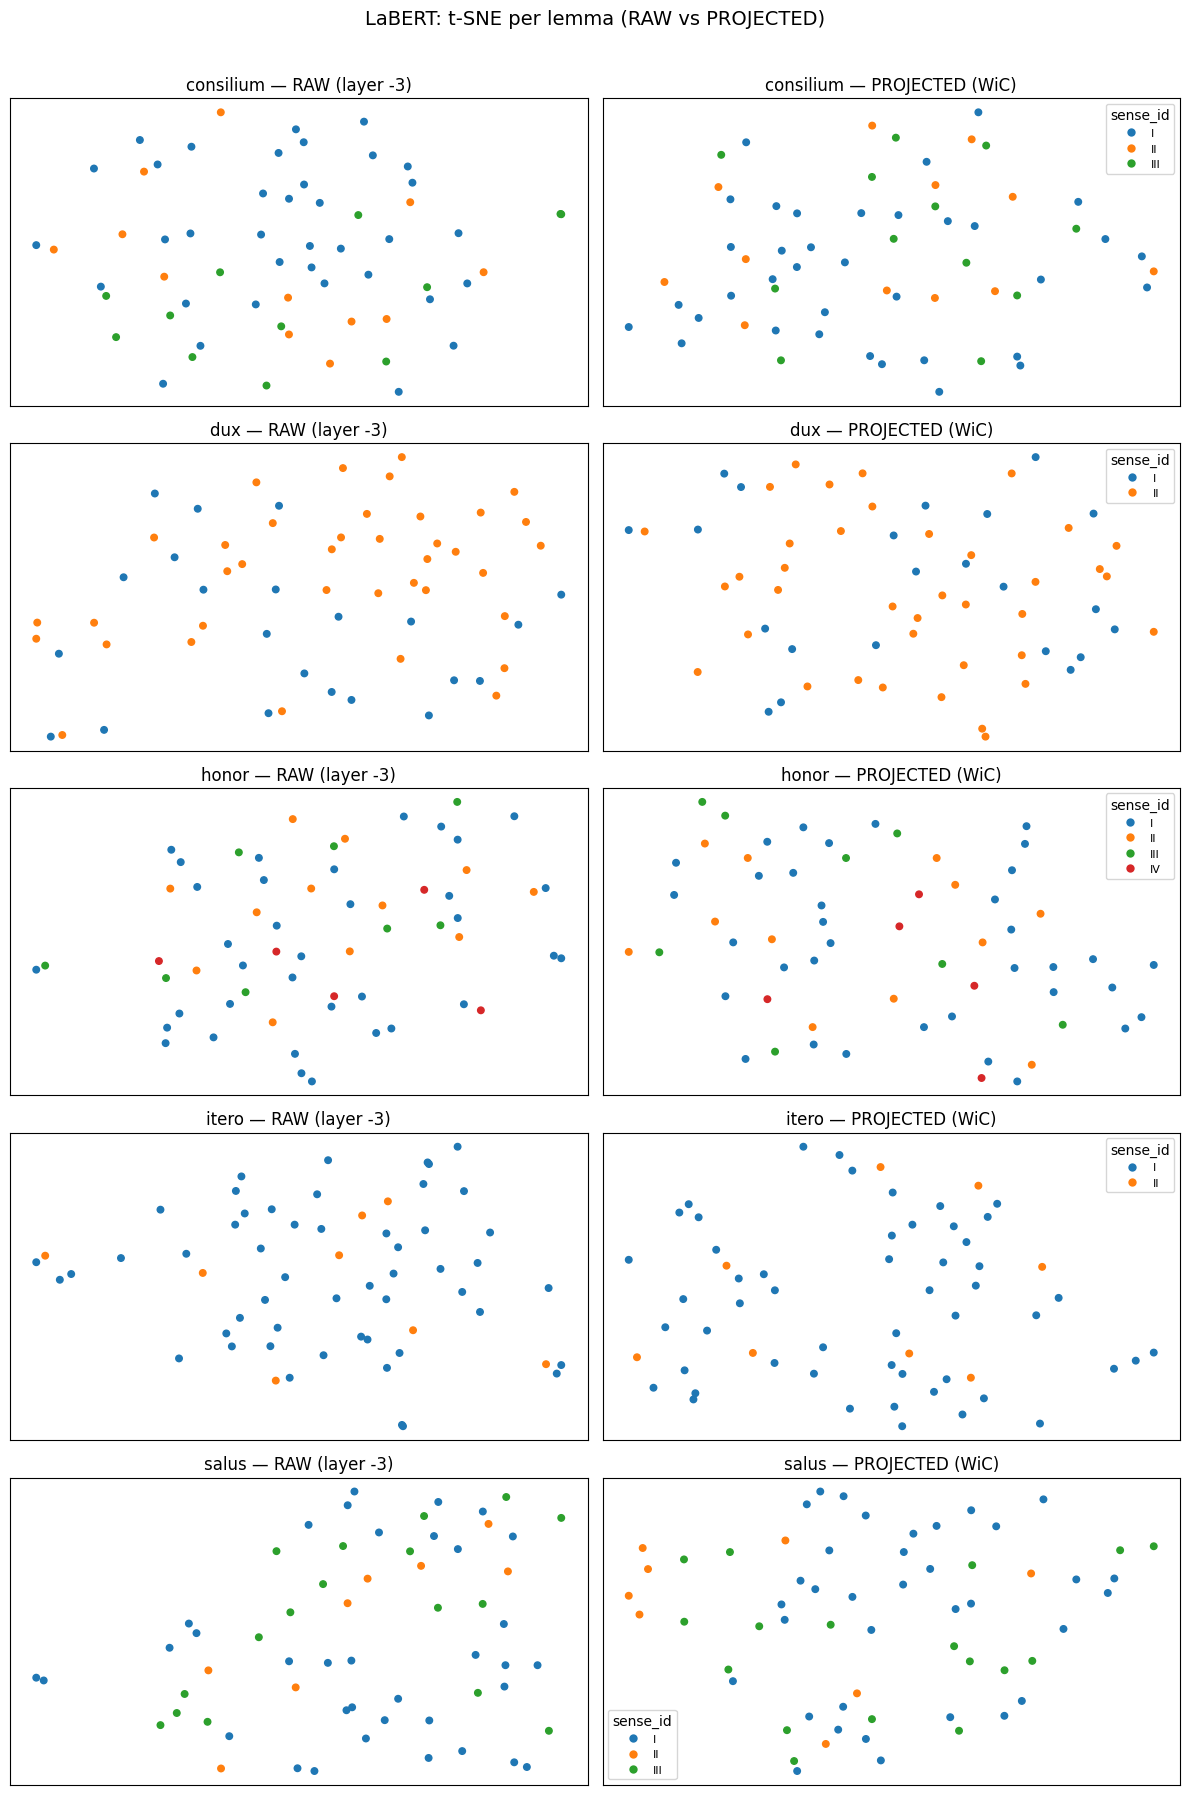

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE

def _pick_lemmas(meta, df, k=5):
    lemma_index = meta["lemma_index"]
    lemmas_60 = [lem for lem, idxs in lemma_index.items() if len(idxs) == 60]
    if len(lemmas_60) >= k:
        return lemmas_60[:k]
    # fallback: top-k by freq
    counts = sorted(((lem, len(idxs)) for lem, idxs in lemma_index.items()), key=lambda x: -x[1])
    return [lem for lem, _ in counts[:k]]

def _tsne_2d(X, perplexity=15, seed=42):
    X = np.asarray(X, dtype=np.float32)
    n = len(X)
    per = perplexity
    return TSNE(
        n_components=2,
        perplexity=per,
        init="random",
        learning_rate="auto",
        random_state=seed,
        n_iter=1000,
        metric="cosine",
    ).fit_transform(X)

def plot_tsne_grid_fixed(vecs_raw, vecs_proj, meta, df, lemmas=None, title_prefix="LaBERT", figsize=(12, 18)):
    lemma_index = meta["lemma_index"]
    if lemmas is None:
        lemmas = _pick_lemmas(meta, df, k=5)

    fig, axes = plt.subplots(len(lemmas), 2, figsize=figsize)
    if len(lemmas) == 1:
        axes = np.array([axes])

    for r, lem in enumerate(lemmas):
        idxs = lemma_index[lem]
        X_raw, X_proj = vecs_raw[idxs], vecs_proj[idxs]
        senses = df.loc[idxs, "sense_id"].astype(str).tolist()
        uniq = sorted(set(senses))
        labmap = {s: i for i, s in enumerate(uniq)}
        y = np.array([labmap[s] for s in senses], dtype=int)
        C = len(uniq)
        cmap = ListedColormap(plt.cm.tab10.colors[:C])

        Y_raw  = _tsne_2d(X_raw,  perplexity=15, seed=42)
        Y_proj = _tsne_2d(X_proj, perplexity=15, seed=42)

        axL, axR = axes[r, 0], axes[r, 1]
        scL = axL.scatter(Y_raw[:, 0],  Y_raw[:, 1],  c=y, s=22, cmap=cmap, vmin=0, vmax=C-1)
        scR = axR.scatter(Y_proj[:, 0], Y_proj[:, 1], c=y, s=22, cmap=cmap, vmin=0, vmax=C-1)

        axL.set_title(f"{lem} — RAW (layer {meta.get('layer_idx', 'last')})")
        axR.set_title(f"{lem} — PROJECTED (WiC)")
        for ax in (axL, axR):
            ax.set_xticks([]); ax.set_yticks([])

        # Legend with *matching colors*
        handles = [plt.Line2D([0],[0], marker='o', linestyle='', markersize=6,
                               markerfacecolor=cmap(i), markeredgecolor='none', label=lbl)
                   for lbl, i in labmap.items()]
        axR.legend(handles=handles, title="sense_id", fontsize=8, loc="best")

    fig.suptitle(f"{title_prefix}: t-SNE per lemma (RAW vs PROJECTED)", y=0.995, fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.985])
    plt.show()

# replot
plot_tsne_grid_fixed(
    vecs_raw=vecs_raw_labert,
    vecs_proj=vecs_proj_labert,
    meta=meta_lab,
    df=semeval_holdout,
    title_prefix="LaBERT"
)

In [39]:
from itertools import combinations
import numpy as np

def sense_separation_report(vecs, df, meta):
    rep = {}
    for lem, idxs in meta["lemma_index"].items():
        y = df.loc[idxs, "sense_id"].astype(str).values
        X = vecs[idxs]
        same, diff = [], []
        for i, j in combinations(range(len(idxs)), 2):
            c = float(np.dot(X[i], X[j]))  # vectors are already L2-normalized
            (same if y[i]==y[j] else diff).append(c)
        if not same or not diff:
            continue
        same = np.array(same); diff = np.array(diff)
        rep[lem] = {
            "same_mean": float(same.mean()),
            "diff_mean": float(diff.mean()),
            "gap": float(same.mean() - diff.mean()),
        }
    return rep

print("RAW separation:")
print(sense_separation_report(vecs_raw_labert, semeval_holdout, meta_lab))
print("\nPROJECTED separation:")
print(sense_separation_report(vecs_proj_labert, semeval_holdout, meta_lab))

RAW separation:
{'consilium': {'same_mean': 0.6613213701510993, 'diff_mean': 0.6544475621647305, 'gap': 0.0068738079863687185}, 'dux': {'same_mean': 0.6454823508188607, 'diff_mean': 0.6273294254495767, 'gap': 0.018152925369284034}, 'honor': {'same_mean': 0.6213488040734428, 'diff_mean': 0.6271556541254095, 'gap': -0.005806850051966683}, 'itero': {'same_mean': 0.7430307568880444, 'diff_mean': 0.7518685995959319, 'gap': -0.008837842707887456}, 'salus': {'same_mean': 0.6405390200250548, 'diff_mean': 0.6259217176486901, 'gap': 0.014617302376364716}}

PROJECTED separation:
{'consilium': {'same_mean': 0.18231886419408963, 'diff_mean': 0.17168943596646255, 'gap': 0.01062942822762708}, 'dux': {'same_mean': 0.16811407259834943, 'diff_mean': 0.1533007984184415, 'gap': 0.014813274179907937}, 'honor': {'same_mean': 0.1067960993540027, 'diff_mean': 0.10596296524961177, 'gap': 0.0008331341043909257}, 'itero': {'same_mean': 0.19991809921992593, 'diff_mean': 0.20531166616330246, 'gap': -0.005393566943

In [63]:
import numpy as np
import networkx as nx

# ---- 1) Read WiC logit scale from payload ----
def load_wic_scale(payload_path, default_scale=2.5):
    pay = torch.load(payload_path, map_location="cpu")
    if "scale_max" in pay and "logit_scale_raw" in pay:
        # bounded temperature: scale_max * sigmoid(raw)
        scale = float(pay["scale_max"]) * float(torch.sigmoid(torch.tensor(pay["logit_scale_raw"])).item())
    elif "logit_scale" in pay:
        scale = float(pay["logit_scale"])
    else:
        scale = float(default_scale)
    return scale

# ---- 2) Projected vectors -> WiC probabilities ----
def prob_matrix_from_projected(X_proj, scale):
    """
    X_proj: [n,d], should already be L2-normalized rows.
    Returns P in [0,1] with ones on the diagonal.
    """
    Xn = X_proj / (np.linalg.norm(X_proj, axis=1, keepdims=True) + 1e-9)
    S = Xn @ Xn.T                             # cosine similarities
    P = 1.0 / (1.0 + np.exp(-scale * S))      # σ(scale * cos)
    # clip tiny num errors and force diag=1
    np.fill_diagonal(P, 1.0)
    return P

# ---- 3) Build a mutual-kNN probability graph (weighted) ----
def prob_mutual_knn_graph(P, k=10, weight_name="w"):
    """
    Mutual-kNN on probabilities. Keeps edges only if i is in j's top-k and j in i's top-k.
    """
    n = P.shape[0]
    # rank descending, skip self at 0
    nbrs = np.argsort(-P, axis=1)[:, 1:k+1]
    Gj = nx.DiGraph()
    Gj.add_nodes_from(range(n))
    for i in range(n):
        for j in nbrs[i]:
            Gj.add_edge(i, int(j), **{weight_name: float(P[i, j])})
    # mutual
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i, j, d in Gj.edges(data=True):
        if Gj.has_edge(j, i):
            w = min(d[weight_name], Gj[j][i][weight_name])  # conservative
            G.add_edge(i, j, **{weight_name: w})
    return G

# (optional) extra pruning by a global τ on weights
def prune_by_tau(G, tau, weight_name="w"):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for u, v, d in G.edges(data=True):
        if d.get(weight_name, 0.0) >= tau:
            H.add_edge(u, v, **d)
    return H

def otsu_tau_from_probs(P):
    """Otsu threshold on the upper-triangular probabilities (ignoring diag)."""
    vals = P[np.triu_indices_from(P, 1)]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return 0.0
    # simple 256-bin Otsu
    hist, edges = np.histogram(vals, bins=256, range=(0.0, 1.0))
    probs = hist.astype(np.float64) / max(1, hist.sum())
    omega = np.cumsum(probs)
    mu = np.cumsum(probs * (edges[:-1] + np.diff(edges)/2))
    mu_t = mu[-1]
    sigma_b2 = (mu_t * omega - mu)**2 / (omega * (1 - omega) + 1e-12)
    k = int(np.nanargmax(sigma_b2))
    return float(edges[k])  # threshold at bin edge

# ---- 4) Community detection (Louvain if available; fallback to greedy modularity) ----
try:
    from community import community_louvain
    HAS_LOUVAIN = True
except Exception:
    HAS_LOUVAIN = False

def communities_labels(G, weight_name="w", resolution=1.0):
    n = G.number_of_nodes()
    if n == 0:
        return np.array([], dtype=int)
    if HAS_LOUVAIN and G.number_of_edges() > 0:
        part = community_louvain.best_partition(G, weight=weight_name, resolution=resolution)
        labs = np.zeros(n, dtype=int)
        for u, c in part.items():
            labs[int(u)] = int(c)
        return labs
    # fallback: greedy modularity (undirected, weighted)
    comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight=weight_name))
    labs = np.zeros(n, dtype=int)
    for cid, S in enumerate(comms):
        for u in S:
            labs[int(u)] = cid
    return labs

In [64]:
# 1) Load scale from your saved head
scale = load_wic_scale(payload_labert)

# 2) Loop lemmas → prob matrix → graph → communities
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

results = []
for lemma, idx in meta_lab["lemma_index"].items():
    # projected vectors for this lemma (already L2-normalized in your pipeline)
    Xp = vecs_proj_labert[idx]

    # 2a) WiC probabilities
    P = prob_matrix_from_projected(Xp, scale=scale)

    # 3) Build mutual-kNN prob graph; k≈min(10, n//3) is a decent default for n≈60
    k = max(5, min(10, len(idx)//3))
    G = prob_mutual_knn_graph(P, k=k, weight_name="w")

    # (optional) prune weak mutual edges with Otsu-picked τ on *all* probs
    tau = otsu_tau_from_probs(P)
    Gτ = prune_by_tau(G, tau=tau, weight_name="w")

    # 4) Communities
    labs = communities_labels(Gτ, weight_name="w", resolution=1.0)

    # Evaluate (if you want): map sense_ids to integers
    gold = semeval_holdout.iloc[idx]["sense_id"].astype("category").cat.codes.to_numpy()
    ari = adjusted_rand_score(gold, labs) if len(np.unique(labs))>1 else 0.0
    nmi = normalized_mutual_info_score(gold, labs) if len(np.unique(labs))>1 else 0.0

    results.append({
        "lemma": lemma,
        "n": len(idx),
        "k_mutual": k,
        "tau": round(tau, 3),
        "clusters": int(len(np.unique(labs))),
        "ARI": round(float(ari), 3),
        "NMI": round(float(nmi), 3),
        "G_edges": G.number_of_edges(),
        "Gτ_edges": Gτ.number_of_edges()
    })

pd.DataFrame(results).sort_values("lemma")

/tmp/ipykernel_465251/4087034859.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pay = torch.load(payload_path, map_location="cpu")


,lemma,n,k_mutual,tau,clusters,ARI,NMI,G_edges,Gτ_edges
0,consilium,60,10,0.602,6,-0.007,0.037,179,178
1,dux,60,10,0.598,6,-0.022,0.012,210,210
2,honor,60,10,0.574,5,0.011,0.094,213,213
3,itero,60,10,0.613,6,-0.014,0.014,189,189
4,salus,60,10,0.594,5,0.111,0.186,218,217


In [65]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- τ policy ---------------------------------------------------------------

def pick_tau(P, mode):
    """
    mode can be:
      - None / "none"  -> no extra pruning (return None)
      - "otsu"         -> Otsu on upper-triangular probs
      - "qNN"          -> e.g. "q90" for 90th percentile
      - float in (0,1) -> explicit threshold
    """
    if mode is None or (isinstance(mode, str) and mode.lower() == "none"):
        return None
    if isinstance(mode, float):
        return float(mode)
    if isinstance(mode, str):
        if mode.lower() == "otsu":
            return otsu_tau_from_probs(P)
        m = re.fullmatch(r"[qQ](\d{1,2})", mode)
        if m:
            q = int(m.group(1))
            vals = P[np.triu_indices_from(P, 1)]
            vals = vals[np.isfinite(vals)]
            return float(np.quantile(vals, q/100.0)) if len(vals) else 0.0
    raise ValueError(f"Unrecognized tau mode: {mode!r}")

# --- main sweep -------------------------------------------------------------

def sweep_prob_graph_params(
    vecs_proj,                  # np.ndarray [N, d], L2-normalized projected vectors for ALL rows
    meta,                       # meta dict with meta["lemma_index"] mapping lemma -> row indices
    df_holdout,                 # original dataframe (to read gold sense ids)
    payload_path,               # to fetch WiC calibration scale
    *,
    ks=(5, 8, 10, 12, 15),
    tau_modes=("none", "otsu", "q90", "q95"),
    resolutions=(0.5, 1.0, 1.5),
    mutual_knn=True,            # keep True (mutual edges are cleaner)
):
    scale = load_wic_scale(payload_path)
    records = []

    for lemma, idx in meta["lemma_index"].items():
        if len(idx) < 5:
            continue
        gold = df_holdout.iloc[idx]["sense_id"].astype("category").cat.codes.to_numpy()
        Xp   = vecs_proj[idx]                      # [n_i, d], should already be unit norm
        P    = prob_matrix_from_projected(Xp, scale=scale)

        for k in ks:
            # 1) base graph (mutual kNN)
            G = prob_mutual_knn_graph(P, k=k, weight_name="w") if mutual_knn else prob_mutual_knn_graph(P, k=k, weight_name="w")

            for tau_mode in tau_modes:
                tau = pick_tau(P, tau_mode)
                G2  = prune_by_tau(G, tau, weight_name="w") if tau is not None else G

                for res in resolutions:
                    labs = communities_labels(G2, weight_name="w", resolution=res)
                    # metrics
                    if len(np.unique(labs)) > 1:
                        ari = adjusted_rand_score(gold, labs)
                        nmi = normalized_mutual_info_score(gold, labs)
                    else:
                        ari = 0.0; nmi = 0.0

                    records.append({
                        "lemma": lemma,
                        "n": len(idx),
                        "k": k,
                        "tau_mode": tau_mode,
                        "tau": round(float(tau), 3) if tau is not None else None,
                        "resolution": res,
                        "clusters": int(len(np.unique(labs))),
                        "ARI": float(ari),
                        "NMI": float(nmi),
                        "edges": G.number_of_edges(),
                        "edges_after": G2.number_of_edges(),
                    })

    df = pd.DataFrame.from_records(records).sort_values(["lemma","ARI","NMI"], ascending=[True,False,False])
    summary = (
        df.groupby(["k","tau_mode","resolution"])[["ARI","NMI","clusters","edges_after"]]
          .mean()
          .sort_values(["ARI","NMI"], ascending=False)
          .reset_index()
    )
    return df, summary

# --- filter & rank for 2–4 clusters -----------------------------------------

def pick_params_for_2to4(df_grid, *, k_range=(6,12), prefer_tau=("q95","otsu")):
    """
    df_grid: output of sweep_prob_graph_params (one row per lemma×k×tau×resolution)
    Returns a ranked table of configs that yield 2–4 clusters, with coverage across lemmas.
    """
    # keep k in a sensible band (optional)
    m = (df_grid["k"] >= k_range[0]) & (df_grid["k"] <= k_range[1])
    sub = df_grid[m].copy()

    # 1) count how often each (k,tau,res) lands 2–4 clusters across lemmas
    grp = (sub.assign(in_range=sub["clusters"].between(2,4))
              .groupby(["k","tau_mode","resolution"])
              .agg(coverage=("in_range","sum"),
                   mean_ARI=("ARI","mean"),
                   mean_NMI=("NMI","mean"),
                   mean_clusters=("clusters","mean"),
                   mean_edges=("edges_after","mean"))
              .reset_index())

    # 2) prefer tau modes if requested (q95/otsu usually help reduce over-merge)
    tau_order = {t:i for i,t in enumerate(prefer_tau)}
    grp["tau_pref_rank"] = grp["tau_mode"].map(lambda t: tau_order.get(t, len(tau_order)+1))

    # 3) rank: coverage (desc) → tau preference → ARI → NMI → closer to 3 clusters
    grp["dist_to_3"] = (grp["mean_clusters"] - 3.0).abs()
    grp = grp.sort_values(
        ["coverage","tau_pref_rank","mean_ARI","mean_NMI","dist_to_3"],
        ascending=[False, True, False, False, True]
    )

    return grp

# --- show per-lemma diagnostics for a chosen config --------------------------

def inspect_config(df_grid, k, tau_mode, resolution):
    """
    Print one row per lemma for the chosen (k,tau,res).
    """
    view = (df_grid[(df_grid["k"]==k) &
                    (df_grid["tau_mode"]==tau_mode) &
                    (df_grid["resolution"]==resolution)]
            .sort_values("lemma"))
    cols = ["lemma","clusters","ARI","NMI","edges_after"]
    return view[cols].reset_index(drop=True)

In [66]:
# 1) run your sweep (as you did)
df_grid, summary = sweep_prob_graph_params(
    vecs_proj_labert, meta_lab, semeval_holdout, payload_labert,
    ks=(6,8,10,12),                 # tighter k band helps hit 2–4 clusters
    tau_modes=("q95","otsu","q90"), # prefer stronger pruning first
    resolutions=(0.7,0.9,1.0,1.2)   # resolution controls #clusters
)

# 2) pick configs that yield 2–4 clusters and rank them
ranked = pick_params_for_2to4(df_grid, k_range=(6,12), prefer_tau=("q95","otsu"))
display(ranked.head(10))

# 3) inspect the top candidate across lemmas
top = ranked.iloc[0]
k, tau_mode, res = int(top.k), top.tau_mode, float(top.resolution)
display(inspect_config(df_grid, k, tau_mode, res))
print(f"\nSuggested default → k={k}, tau='{tau_mode}', resolution={res:.2f}")

/tmp/ipykernel_465251/4087034859.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pay = torch.load(payload_path, map_location="cpu")


,k,tau_mode,resolution,coverage,mean_ARI,mean_NMI,mean_clusters,mean_edges,tau_pref_rank,dist_to_3
37,12,otsu,0.9,1,0.000743,0.064186,5.4,248.8,1,2.4
10,6,q95,1.0,0,0.004253,0.163066,20.6,73.0,0,17.6
44,12,q95,0.7,0,0.002626,0.169425,19.0,88.8,0,16.0
21,8,q95,0.9,0,0.002480,0.157626,18.8,84.0,0,15.8
45,12,q95,0.9,0,0.001885,0.154142,18.4,88.8,0,15.4
46,12,q95,1.0,0,0.001814,0.164781,19.0,88.8,0,16.0
11,6,q95,1.2,0,0.001630,0.174861,21.4,73.0,0,18.4
9,6,q95,0.9,0,0.000744,0.165201,20.6,73.0,0,17.6
8,6,q95,0.7,0,0.000189,0.164196,20.0,73.0,0,17.0
32,10,q95,0.7,0,-0.000885,0.165729,20.0,87.4,0,17.0


,lemma,clusters,ARI,NMI,edges_after
0,consilium,5,0.022543,0.071314,225
1,dux,4,-0.018528,0.004589,253
2,honor,7,-0.004939,0.122366,260
3,itero,6,-0.012064,0.014633,238
4,salus,5,0.016704,0.108028,268



Suggested default → k=12, tau='otsu', resolution=0.90


In [43]:
import numpy as np
from sklearn.cluster import OPTICS
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

# ---------- 1) cosine similarity ----------
def cosine_sim_matrix(X: np.ndarray) -> np.ndarray:
    # rows are samples; L2 normalize then dot product
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return Xn @ Xn.T  # faster than sklearn for dense

# ---------- 2) HDBSCAN (if available) ----------
def hdbscan_clusters(X: np.ndarray, min_cluster_size: int = 5, min_samples=None, metric: str = "euclidean"):
    """
    Returns:
      labels: np.array shape [n], cluster ids (−1=noise)
      info:   dict with keys: algo, n_clusters, noise_frac
    """
    try:
        import hdbscan
    except Exception as e:
        raise RuntimeError(
            "hdbscan is not installed. Install it (e.g. `pip install hdbscan`) "
            "or use optics_clusters/graph-based methods."
        ) from e
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples,
                                metric=metric)
    labels = clusterer.fit_predict(X)
    n = len(labels)
    n_noise = int((labels == -1).sum())
    n_clu = len(set(labels) - {-1})
    info = {
        "algo": "hdbscan",
        "n_clusters": int(n_clu),
        "noise_frac": float(n_noise / max(1, n)),
    }
    return labels.astype(np.int32), info

# ---------- 3) OPTICS (no k) ----------
def optics_clusters(X: np.ndarray, min_samples: int = 5, xi: float = 0.05, metric: str = "euclidean"):
    """
    Sklearn OPTICS with xi extraction (clusters of varying density).
    Returns labels (−1 noise) and info dict.
    """
    opt = OPTICS(min_samples=min_samples, xi=xi, metric=metric, cluster_method="xi")
    labels = opt.fit_predict(X)
    n = len(labels)
    n_noise = int((labels == -1).sum())
    n_clu = len(set(labels) - {-1})
    info = {
        "algo": "optics_xi",
        "n_clusters": int(n_clu),
        "noise_frac": float(n_noise / max(1, n)),
        "xi": float(xi),
        "min_samples": int(min_samples),
    }
    return labels.astype(np.int32), info

# ---------- 4) Graph components via adaptive threshold ----------
def _otsu_threshold(values: np.ndarray) -> float:
    """
    Otsu on [0,1] similarities (1D). Lightweight implementation.
    Expects a 1D array of similarities (off-diagonal).
    """
    vals = np.clip(values[np.isfinite(values)], 0.0, 1.0)
    if vals.size == 0:
        return 0.5
    hist, bin_edges = np.histogram(vals, bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * (bin_edges[:-1] + bin_edges[1:]) / 2.0)
    mu_t = mu[-1]
    sigma_b2 = (mu_t * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)
    idx = int(np.nanargmax(sigma_b2))
    # threshold between the two bins at idx and idx+1
    return (bin_edges[idx] + bin_edges[idx + 1]) / 2.0
import numpy as np
import networkx as nx

# ---------- Build the raw graph ----------

def graph_from_sim(S: np.ndarray, weight_name: str = "weight") -> nx.Graph:
    """
    Make a fully weighted, undirected graph from a similarity matrix S (n x n).
    - No thresholding, no pruning, no self-loops.
    - Edge attribute: {weight_name: float(sim)}
    """
    S = np.asarray(S)
    n = S.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    # add only i<j to avoid duplicates
    for i in range(n):
        # skip diagonal and zeros (optional; comment out if you truly want complete)
        for j in range(i + 1, n):
            w = float(S[i, j])
            if w > 0.0:
                G.add_edge(i, j, **{weight_name: w})
    return G

# ---------- Thresholding / pruning utilities ----------

def threshold_graph(G: nx.Graph, tau: float, weight_name: str = "weight", mode: str = "above") -> nx.Graph:
    """
    Keep edges with weight >= tau (mode='above') or <= tau (mode='below').
    Returns a NEW graph (nodes preserved).
    """
    keep = []
    for u, v, d in G.edges(data=True):
        w = d.get(weight_name, 0.0)
        if (mode == "above" and w >= tau) or (mode == "below" and w <= tau):
            keep.append((u, v, d))
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(keep)
    return H

def quantile_threshold(G: nx.Graph, q: float, weight_name: str = "weight", mode: str = "above") -> nx.Graph:
    """
    Keep edges above (or below) the q-quantile of weights.
    """
    ws = np.array([d.get(weight_name, 0.0) for *_ , d in G.edges(data=True)], dtype=float)
    if ws.size == 0:
        return G.copy()
    tau = float(np.quantile(ws, q))
    return threshold_graph(G, tau, weight_name=weight_name, mode=mode)

def knn_graph_from_sim(S: np.ndarray, k: int = 10, sym: str = "mutual", weight_name: str = "weight") -> nx.Graph:
    """
    kNN graph (no global threshold). sym in {'mutual','union'}.
    """
    S = np.asarray(S)
    n = S.shape[0]
    # argsort descending per row (ignore self)
    idx = np.argsort(-S, axis=1)
    knn = [set(row[row != i][:k]) for i, row in enumerate(idx)]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in knn[i]:
            if sym == "mutual" and i not in knn[j]:
                continue
            if j <= i:
                continue
            w = float(S[i, j])
            if w > 0.0:
                G.add_edge(i, j, **{weight_name: w})
    return G

# ---------- Community helpers (you can mix & match later) ----------

def run_louvain(G: nx.Graph, weight_name: str = "weight", resolution: float = 1.0):
    """
    Requires python-louvain: `pip install python-louvain`
    Returns: labels (np.array of length |V| ordered by node id)
    """
    import community as community_louvain
    part = community_louvain.best_partition(G, weight=weight_name, resolution=resolution)
    # ensure array in node-id order
    return np.array([part[i] for i in sorted(G.nodes())], dtype=int)

def run_label_prop(G: nx.Graph):
    """
    NetworkX label propagation (unweighted). Returns labels array.
    """
    coms = list(nx.algorithms.community.label_propagation_communities(G))
    lab = np.empty(len(G), dtype=int)
    for cid, C in enumerate(coms):
        for u in C:
            lab[u] = cid
    return lab

In [52]:
# ========= dependencies =========
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import OPTICS
import networkx as nx

# --- optional: HDBSCAN ---
try:
    import hdbscan
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False

# --- optional: Louvain (python-louvain) ---
try:
    import community as community_louvain  # pip install python-louvain
    HAS_LOUVAIN = True
except Exception:
    community_louvain = None
    HAS_LOUVAIN = False

# ========= helpers =========
def _l2norm(X):  # L2-normalize rows
    n = np.linalg.norm(X, axis=1, keepdims=True) + 1e-9
    return X / n

as_unit = _l2norm  # alias (reads nicer in your code)

def _autos(hint_n, frac, floor):
    return int(max(floor, round(frac * hint_n)))

def to_cos_silhouette(X, labels):
    # cosine silhouette via precomputed distances
    if len(np.unique(labels)) < 2:
        return np.nan
    S = cosine_similarity(X)
    D = 1.0 - S
    return silhouette_score(D, labels, metric="precomputed")

# ========= clustering (no-graph) =========
def run_hdbscan(X, n_samples_for_params=None, min_cluster_frac=0.06, min_samples_frac=0.04):
    """
    HDBSCAN with cosine-equivalent geometry via L2-normalization + euclidean.
    min_cluster_size / min_samples set adaptively from sample size.
    """
    if not HAS_HDBSCAN:
        labs = np.full(len(X), -1, dtype=int)
        return labs, {"k":0, "noise_frac":1.0, "min_cluster_size":None, "min_samples":None}

    n = int(n_samples_for_params or len(X))
    min_cluster_size = _autos(n, min_cluster_frac, floor=3)
    min_samples      = _autos(n, min_samples_frac, floor=2)

    Xn = _l2norm(X)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean"
    )
    labels = clusterer.fit_predict(Xn)
    k = len(np.unique(labels[labels >= 0])) if (labels >= 0).any() else 0
    noise_frac = float((labels < 0).mean())
    return labels, {"k": k, "noise_frac": noise_frac,
                    "min_cluster_size": min_cluster_size, "min_samples": min_samples}

def run_optics(X, n_samples_for_params=None, min_samples_frac=0.04, xi=0.05):
    """
    OPTICS with cosine-equivalent geometry via L2-normalization + euclidean.
    """
    n = int(n_samples_for_params or len(X))
    min_samples = _autos(n, min_samples_frac, floor=2)

    Xn = _l2norm(X)
    optics = OPTICS(min_samples=min_samples, metric="euclidean", cluster_method="xi", xi=xi)
    labels = optics.fit_predict(Xn)
    k = len(np.unique(labels[labels >= 0])) if (labels >= 0).any() else 0
    noise_frac = float((labels < 0).mean())
    return labels, {"k": k, "noise_frac": noise_frac, "min_samples": min_samples}

# ========= graph builders =========
def graph_from_sim(S, weight_name="w", keep_upper=True):
    n = S.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    it = np.triu_indices(n, k=1) if keep_upper else np.where(~np.eye(n, dtype=bool))
    for i, j in zip(it[0], it[1]):
        w = float(S[i, j])
        if np.isfinite(w):
            G.add_edge(int(i), int(j), **{weight_name: w})
    return G

def threshold_graph(G, tau, weight_name="w"):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    for u, v, d in G.edges(data=True):
        if d.get(weight_name, 0.0) >= tau:
            H.add_edge(u, v, **d)
    return H

def knn_graph_from_sim(S, k=10, weight_name="w", sym="mutual"):
    # Build directed kNN then optionally symmetrize
    n = S.shape[0]
    nbrs = np.argsort(-S, axis=1)[:, 1:k+1]  # skip self at rank 0
    Gj = nx.DiGraph()
    Gj.add_nodes_from(range(n))
    for i in range(n):
        for j in nbrs[i]:
            Gj.add_edge(i, int(j), **{weight_name: float(S[i, j])})
    if sym == "mutual":
        H = nx.Graph()
        H.add_nodes_from(Gj.nodes())
        for i, j, d in Gj.edges(data=True):
            if Gj.has_edge(j, i):
                w = min(d[weight_name], Gj[j][i][weight_name])
                H.add_edge(i, j, **{weight_name: w})
        return H
    else:  # 'union'
        return Gj.to_undirected()

# ========= community detection =========
def _sets_to_labels(sets, n):
    lab = np.zeros(n, dtype=int)
    for cid, S in enumerate(sets):
        for u in S:
            lab[int(u)] = cid
    return lab

def run_louvain(G, weight_name="w", resolution=1.0):
    if HAS_LOUVAIN:
        part = community_louvain.best_partition(G, weight=weight_name, resolution=resolution)
        n = G.number_of_nodes()
        labels = np.zeros(n, dtype=int)
        for u, c in part.items():
            labels[int(u)] = int(c)
        return labels
    # fallback: NetworkX label propagation
    sets = list(nx.algorithms.community.label_propagation_communities(G))
    return _sets_to_labels(sets, G.number_of_nodes())

# ========= metrics =========
def labelled_metrics(labels_pred, labels_gold, X_for_sil=None):
    # Replace all-negative case with a single cluster to make ARI/NMI defined
    if np.all(labels_pred < 0):
        labels_pred = np.zeros_like(labels_pred)
        k = 1
        noise_frac = 0.0
    else:
        k = len(np.unique(labels_pred[labels_pred>=0])) if (labels_pred>=0).any() else 1
        noise_frac = float((labels_pred < 0).mean())
        # map noise to its own cluster id for ARI/NMI (optional)
        if (labels_pred == -1).any():
            m = labels_pred.max() + 1
            labels_pred = labels_pred.copy()
            labels_pred[labels_pred == -1] = m

    ari = adjusted_rand_score(labels_gold, labels_pred)
    nmi = normalized_mutual_info_score(labels_gold, labels_pred)
    sil = np.nan
    if X_for_sil is not None and len(np.unique(labels_pred)) > 1:
        try:
            sil = to_cos_silhouette(X_for_sil, labels_pred)
        except Exception:
            sil = np.nan
    return {"k":k, "noise_frac":noise_frac, "ARI":ari, "NMI":nmi, "sil":sil}

In [62]:
records = []
target_lemmas = semeval_holdout["lemma"].astype(str).unique()

for lemma in target_lemmas:
    # skip lemmas that somehow didn't make it into the index
    if lemma not in meta_lab["lemma_index"]:
        continue

    idx = meta_lab["lemma_index"][lemma]
    y_gold = semeval_holdout.iloc[idx]["sense_id"].astype("category").cat.codes.to_numpy()

    Xr = as_unit(vecs_raw_labert[idx])
    Xp = as_unit(vecs_proj_labert[idx])
    n_i = len(idx)

    # --- clustering (no-graph), adaptive to n_i ---
    labs_hdb_r, info_r  = run_hdbscan(Xr, n_samples_for_params=n_i)
    labs_hdb_p, info_p  = run_hdbscan(Xp, n_samples_for_params=n_i)

    labs_opt_r, infoo_r = run_optics(Xr, n_samples_for_params=n_i, xi=0.05)
    labs_opt_p, infoo_p = run_optics(Xp, n_samples_for_params=n_i, xi=0.05)

    # --- graphs once per space ---
    Sr = cosine_similarity(Xr);  Sp = cosine_similarity(Xp)

    # keep ~top 10% strongest edges (adjust if too sparse/dense)
    tau_r = np.quantile(Sr[np.triu_indices_from(Sr, 1)], 0.90)
    tau_p = np.quantile(Sp[np.triu_indices_from(Sp, 1)], 0.90)

    Gr_raw = graph_from_sim(Sr, weight_name="w")
    Gp_raw = graph_from_sim(Sp, weight_name="w")

    Gr = threshold_graph(Gr_raw, tau=tau_r, weight_name="w")
    Gp = threshold_graph(Gp_raw, tau=tau_p, weight_name="w")

    labs_louv_r = run_louvain(Gr, weight_name="w", resolution=1.0)
    labs_louv_p = run_louvain(Gp, weight_name="w", resolution=1.0)

    # mutual-kNN (k=10) graphs
    Gr_knn = knn_graph_from_sim(Sr, k=10, sym="mutual", weight_name="w")
    Gp_knn = knn_graph_from_sim(Sp, k=10, sym="mutual", weight_name="w")

    labs_louv_r_knn = run_louvain(Gr_knn, weight_name="w", resolution=1.0)
    labs_louv_p_knn = run_louvain(Gp_knn, weight_name="w", resolution=1.0)

    # --- collect metrics ---
    rows = []
    rows.append({"lemma":lemma, "space":"RAW",  "method":"HDBSCAN",      **labelled_metrics(labs_hdb_r, y_gold, Xr)})
    rows.append({"lemma":lemma, "space":"PROJ", "method":"HDBSCAN",      **labelled_metrics(labs_hdb_p, y_gold, Xp)})

    rows.append({"lemma":lemma, "space":"RAW",  "method":"OPTICS",       **labelled_metrics(labs_opt_r, y_gold, Xr)})
    rows.append({"lemma":lemma, "space":"PROJ", "method":"OPTICS",       **labelled_metrics(labs_opt_p, y_gold, Xp)})

    rows.append({"lemma":lemma, "space":"RAW",  "method":"Louvain τ90",  **labelled_metrics(labs_louv_r, y_gold, Xr)})
    rows.append({"lemma":lemma, "space":"PROJ", "method":"Louvain τ90",  **labelled_metrics(labs_louv_p, y_gold, Xp)})

    rows.append({"lemma":lemma, "space":"RAW",  "method":"Louvain kNN10",**labelled_metrics(labs_louv_r_knn, y_gold, Xr)})
    rows.append({"lemma":lemma, "space":"PROJ", "method":"Louvain kNN10",**labelled_metrics(labs_louv_p_knn, y_gold, Xp)})

    records.extend(rows)

# ----- tables -----
df_all = pd.DataFrame.from_records(records)

# Per-lemma report
for lemma in df_all["lemma"].unique():
    print(f"\n=== {lemma} ===")
    display(
        df_all[df_all["lemma"]==lemma]
          .sort_values(["space","ARI","NMI"], ascending=[True, False, False])
          .reset_index(drop=True)
          .round(3)
    )

# Overall (mean over lemmas)
print("\n=== overall (mean over lemmas) ===")
display(
    df_all.groupby(["space","method"])[["ARI","NMI","sil","k","noise_frac"]]
         .mean()
         .sort_values(["space","ARI","NMI"], ascending=[True, False, False])
         .round(3)
)

/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv


=== consilium ===


/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,lemma,space,method,k,noise_frac,ARI,NMI,sil
0,consilium,PROJ,Louvain kNN10,7,0.000,-0.015,0.062,NaN
1,consilium,PROJ,Louvain τ90,13,0.000,-0.016,0.119,NaN
2,consilium,PROJ,OPTICS,9,0.683,-0.031,0.126,NaN
3,consilium,PROJ,HDBSCAN,2,0.783,-0.052,0.029,NaN
4,consilium,RAW,OPTICS,2,0.933,0.066,0.109,NaN
5,consilium,RAW,Louvain τ90,14,0.000,0.050,0.200,NaN
6,consilium,RAW,Louvain kNN10,12,0.000,0.026,0.146,NaN
7,consilium,RAW,HDBSCAN,2,0.717,-0.058,0.046,NaN



=== dux ===


...

,lemma,space,method,k,noise_frac,ARI,NMI,sil
0,itero,PROJ,HDBSCAN,3,0.517,0.033,0.025,NaN
1,itero,PROJ,OPTICS,9,0.617,-0.010,0.059,NaN
2,itero,PROJ,Louvain kNN10,8,0.000,-0.013,0.018,NaN
3,itero,PROJ,Louvain τ90,10,0.000,-0.016,0.022,NaN
4,itero,RAW,OPTICS,6,0.783,0.108,0.076,NaN
5,itero,RAW,Louvain kNN10,9,0.000,-0.008,0.044,NaN
6,itero,RAW,Louvain τ90,9,0.000,-0.012,0.053,NaN
7,itero,RAW,HDBSCAN,2,0.483,-0.016,0.003,NaN



=== salus ===


,lemma,space,method,k,noise_frac,ARI,NMI,sil
0,salus,PROJ,Louvain τ90,8,0.000,0.076,0.214,NaN
1,salus,PROJ,HDBSCAN,2,0.217,0.039,0.041,NaN
2,salus,PROJ,Louvain kNN10,5,0.000,0.028,0.106,NaN
3,salus,PROJ,OPTICS,12,0.433,-0.057,0.191,NaN
4,salus,RAW,Louvain τ90,12,0.000,0.078,0.230,NaN
5,salus,RAW,Louvain kNN10,7,0.000,0.039,0.115,NaN
6,salus,RAW,HDBSCAN,2,0.450,-0.015,0.084,NaN
7,salus,RAW,OPTICS,7,0.683,-0.111,0.196,NaN



=== overall (mean over lemmas) ===


ARI    NMI  sil     k  noise_frac
space method                                            
PROJ  Louvain τ90    0.015  0.110  NaN   9.4       0.000
      HDBSCAN       -0.000  0.028  NaN   2.2       0.477
      Louvain kNN10 -0.004  0.055  NaN   6.2       0.000
      OPTICS        -0.022  0.121  NaN   9.2       0.607
RAW   Louvain τ90    0.026  0.159  NaN  12.4       0.000
      Louvain kNN10  0.016  0.115  NaN   9.0       0.000
      OPTICS         0.010  0.129  NaN   5.0       0.793
      HDBSCAN       -0.030  0.064  NaN   2.0       0.603

In [61]:
import community
importlib.reload(community)

<module 'community' from '/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/community/__init__.py'>

In [49]:
lab_opt

array([ 0,  1, -1,  1, -1,  3, -1, -1, -1, -1, -1, -1,  4, -1, -1,  4, -1,
       -1, -1, -1,  5, -1, -1, -1, -1, -1,  0, -1,  3, -1, -1, -1, -1, -1,
       -1,  0,  4, -1, -1,  1, -1, -1, -1, -1,  2,  4, -1, -1, -1, -1, -1,
       -1,  5, -1, -1, -1,  2, -1, -1, -1], dtype=int32)

## Make cos-sim matrices and networks

In [20]:
import numpy as np
import pandas as pd

def _cosim_matrix(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Row-wise cosine similarity matrix for X (n x d).
    Re-normalizes rows defensively (even if they’re already normalized).
    """
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    Xn = X / norms
    return (Xn @ Xn.T).astype(np.float32)

# Group rows by lemma and build cosine matrices
lemma2cosim = {}
lemma2indices = {}  # keep which rows of semeval_holdout correspond to each matrix row/col

for lemma, idxs in semeval_holdout.groupby("lemma").indices.items():
    idxs = np.array(list(idxs))
    X = vecs_labert[idxs]             # slice embeddings for this lemma
    C = _cosim_matrix(X)              # (n x n) cosine matrix
    lemma2cosim[lemma] = C
    lemma2indices[lemma] = idxs

# Quick sanity print (sizes should be 60x60 each in your setup)
for lemma, C in lemma2cosim.items():
    print(f"{lemma}: {C.shape}  diag≈{np.mean(np.diag(C)):.3f}, offdiag mean={np.mean(C - np.eye(C.shape[0])):.3f}")

# (Optional) save to disk
out_dir = "../data/embeddings/cosim_by_lemma"
import os; os.makedirs(out_dir, exist_ok=True)
for lemma, C in lemma2cosim.items():
    safe = "".join(ch if ch.isalnum() else "_" for ch in str(lemma))
    np.save(os.path.join(out_dir, f"{safe}_cosim.npy"), C)
    np.save(os.path.join(out_dir, f"{safe}_row_indices.npy"), lemma2indices[lemma])

consilium: (60, 60)  diag≈1.000, offdiag mean=0.124
dux: (60, 60)  diag≈1.000, offdiag mean=0.152
honor: (60, 60)  diag≈1.000, offdiag mean=0.102
itero: (60, 60)  diag≈1.000, offdiag mean=0.144
salus: (60, 60)  diag≈1.000, offdiag mean=0.105


In [ ]:
import numpy as np

def l2_normalize(X, eps=1e-8):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def cosine_sim_matrix(X):
    Xn = l2_normalize(X)
    return Xn @ Xn.T

In [21]:
def hdbscan_clusters(X, min_cluster_size=5, min_samples=None):
    import hdbscan
    Xn = l2_normalize(X)
    cl = hdbscan.HDBSCAN(metric="euclidean",
                         min_cluster_size=min_cluster_size,
                         min_samples=min_samples)
    labels = cl.fit_predict(Xn)                 # noise = -1
    return labels, {"n_clusters": int((labels >= 0).sum() and labels.max()+1),
                    "noise_frac": float(np.mean(labels == -1))}

def optics_clusters(X, min_samples=5, xi=0.05):
    from sklearn.cluster import OPTICS
    Xn = l2_normalize(X)
    cl = OPTICS(metric="euclidean", min_samples=min_samples, xi=xi)
    labels = cl.fit_predict(Xn)                 # noise = -1
    return labels, {"n_clusters": int((labels >= 0).sum() and labels.max()+1),
                    "noise_frac": float(np.mean(labels == -1))}

In [22]:
import networkx as nx
from community import community_louvain
import networkx as nx

ImportError: cannot import name 'community_louvain' from 'community' (/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/community/__init__.py)

In [ ]:
def otsu_threshold(values):
    """1D Otsu threshold (fast, good default to split low/high sims)."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    v = (v - v.min()) / (v.max() - v.min() + 1e-12)
    hist, bin_edges = np.histogram(v, bins=256, range=(0,1))
    w = np.cumsum(hist)
    mu = np.cumsum(hist * (bin_edges[:-1] + bin_edges[1:]) / 2)
    mu_t = mu[-1]
    sigma_b2 = (mu_t * w - mu)**2 / (w * (w.max() - w + 1e-12))
    t_idx = np.nanargmax(sigma_b2)
    return (bin_edges[t_idx] + bin_edges[t_idx+1]) / 2

def graph_components_from_sim(S, tau="otsu"):
    """S: NxN similarity (cosine or WiC probs). Returns comp labels."""
    N = S.shape[0]
    if isinstance(tau, str) and tau == "otsu":
        upper = S[np.triu_indices(N, k=1)]
        tau = float(otsu_threshold(upper))
    G = nx.Graph()
    G.add_nodes_from(range(N))
    ii, jj = np.triu_indices(N, k=1)
    keep = (S[ii, jj] >= tau)
    edges = [(int(i), int(j), float(S[i, j])) for i, j in zip(ii[keep], jj[keep])]
    G.add_weighted_edges_from(edges)
    comps = list(nx.connected_components(G))
    labels = np.full(N, -1, dtype=int)
    for cid, nodes in enumerate(comps):
        for u in nodes: labels[u] = cid
    return labels, {"tau": float(tau), "n_clusters": len(comps)}

In [ ]:
def louvain_auto_from_sim(S, resolutions=(0.5, 0.8, 1.0, 1.2, 1.5)):
    N = S.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(N))
    ii, jj = np.triu_indices(N, k=1)
    edges = [(int(i), int(j), float(S[i, j])) for i, j in zip(ii, jj)]
    G.add_weighted_edges_from(edges)

    best = None
    for res in resolutions:
        part = community_louvain.best_partition(G, weight="weight", resolution=res, random_state=42)
        Q = community_louvain.modularity(part, G, weight="weight")
        labels = np.array([part[i] for i in range(N)], dtype=int)
        # penalize too many singletons a bit (optional, can remove)
        singleton_penalty = (labels == -1).sum() / max(1, N)
        score = Q - 0.05 * singleton_penalty
        if best is None or score > best[0]:
            best = (score, res, labels, Q)
    _, res_star, labels, Q_star = best
    return labels, {"resolution": res_star, "modularity": Q_star}

In [ ]:
# X_proj: your WiC-projected vectors for that lemma (n_i x d)
# X_raw : baseline contextual vectors for that lemma (n_i x d)

# Vector-space, no k
lab_hdb, d1 = hdbscan_clusters(X_proj, min_cluster_size=5)
lab_opt, d2 = optics_clusters(X_proj, min_samples=5, xi=0.05)

# Graph from similarities (use your WiC probabilities or cosine)
S_proj = cosine_sim_matrix(X_proj)     # or your WiC-prob matrix directly
lab_cc,  d3 = graph_components_from_sim(S_proj, tau="otsu")     # adaptive τ
lab_louv, d4 = louvain_auto_from_sim(S_proj)                    # auto resolution

print(d1, d2, d3, d4)

In [ ]:
# --- rebuild the head-only module for inference ---
import torch.nn as nn
import torch.nn.functional as F

class TargetSpanPooler(nn.Module):
    def forward(self, hidden, spans):
        B, L, D = hidden.shape
        cls = hidden[:, 0, :]
        out = []
        for b, idxs in enumerate(spans):
            if isinstance(idxs, (list, tuple)) and len(idxs) > 0:
                out.append(hidden[b, idxs, :].mean(dim=0))
            else:
                out.append(cls[b])
        return torch.stack(out, dim=0)

class WiCHeadForEval(nn.Module):
    def __init__(self, encoder, payload):
        super().__init__()
        self.encoder = encoder
        self.layer_idx = payload["layer_idx"]
        self.scale_max = payload["scale_max"]
        self.logit_scale_raw = nn.Parameter(torch.tensor(float(payload["logit_scale_raw"])), requires_grad=False)
        D = payload["enc_hidden_size"]; P = payload["proj_out_dim"]
        self.proj = nn.Sequential(
            nn.Linear(D, P), nn.ReLU(inplace=True), nn.Dropout(0.1), nn.LayerNorm(P),
        )
        self.proj.load_state_dict(payload["proj_state_dict"])
        self.pool = TargetSpanPooler()

    def _scale(self):
        return self.scale_max * torch.sigmoid(self.logit_scale_raw)

    @torch.no_grad()
    def _encode(self, ids, mask):
        outs = self.encoder(input_ids=ids, attention_mask=mask, output_hidden_states=True)
        if self.layer_idx is None:
            H = outs.last_hidden_state
        else:
            idx = self.layer_idx
            if idx < 0: idx = len(outs.hidden_states) + idx
            H = outs.hidden_states[idx]
        return H

    @torch.no_grad()
    def forward(self, batch):
        H1 = self._encode(batch["input_ids_1"], batch["attention_mask_1"])
        H2 = self._encode(batch["input_ids_2"], batch["attention_mask_2"])
        z1 = self.pool(H1, batch["spans_1"])
        z2 = self.pool(H2, batch["spans_2"])
        e1 = F.normalize(self.proj(z1), dim=-1)
        e2 = F.normalize(self.proj(z2), dim=-1)
        logits = (e1 * e2).sum(dim=1) * self._scale()
        return logits.sigmoid(), e1, e2

wic_head = WiCHeadForEval(encoder_model, payload).eval().to("cuda")

# --- build evaluation loader from your holdout ---
wic_df_eval = semeval_holdout_proc.copy()

wic_ds_eval = WiCPairDataset(
    wic_df_eval,
    pos_frac=0.5,             # balanced eval sample
    pairs_per_epoch=5000,     # evaluate on a fixed large sample (you can raise)
    seed=777,
)
wic_collate_eval = wsd_io.WiCPairCollator(tokenizer, model_kind="labert", use_lemma_view=True, max_len=payload["max_len"])

wic_dl_eval = DataLoader(
    wic_ds_eval, batch_size=64, shuffle=False, num_workers=0,
    collate_fn=lambda batch: wic_collate_eval(batch, rows=wic_ds_eval.rows),
)

# --- run evaluation (scores + basic metrics) ---
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

probs_all, ys_all = [], []
with torch.no_grad():
    for batch in wic_dl_eval:
        for k in ("input_ids_1","attention_mask_1","input_ids_2","attention_mask_2"):
            batch[k] = batch[k].to("cuda")
        probs, _, _ = wic_head(batch)
        probs_all.append(probs.detach().cpu().numpy())
        ys_all.append(batch["labels"].cpu().numpy())

probs = np.concatenate(probs_all)
ys = np.concatenate(ys_all)

roc = roc_auc_score(ys, probs)
pr  = average_precision_score(ys, probs)

def acc_at(t):
    return accuracy_score(ys, (probs >= t).astype(int))

acc50 = acc_at(0.50)
acc_best = max((acc_at(t), t) for t in np.linspace(0.05, 0.95, 19))

print(f"ROC-AUC={roc:.3f}  PR-AUC={pr:.3f}  ACC@0.50={acc50:.3f}  BestACC={acc_best[0]:.3f} @ t={acc_best[1]:.2f}")

## Embeddings extraction

In [28]:
import numpy as np
import torch

def _ensure_list(x):
    # spans may arrive as numpy arrays
    return [] if x is None else (x.tolist() if hasattr(x, "tolist") else list(x))

def _as_token_list(x):
    # Accept list/tuple/numpy array/Series; flatten to list[str]
    if x is None:
        return []
    if hasattr(x, "tolist"):           # numpy array / Series
        x = x.tolist()
    if isinstance(x, (tuple, set)):
        x = list(x)
    if isinstance(x, str):
        # If it's a stringified list like "['a','b']", try literal_eval; else split on whitespace
        import ast
        try:
            maybe = ast.literal_eval(x)
            if isinstance(maybe, (list, tuple)):
                x = list(maybe)
            else:
                x = x.split()
        except Exception:
            x = x.split()
    # ensure strings
    return [str(t) for t in x]


@torch.no_grad()
def all_layer_target_embedding_single(
    model, tokenizer, *,
    model_kind: str,      # "xlmr" | "labert"
    tokens,               # list[str] (surface or lemma tokens you already built)
    span,                 # list[int] subword indices for the target
    max_len: int = 256,
    device: str = "cpu",
    piece_pool: str = "mean",  # "mean" | "sum"
):
    """
    Returns an array of shape [num_encoder_layers, hidden_dim].
    Excludes the embeddings layer: layer 0 in the output = encoder layer 1 in HF.
    If span is empty -> returns None.
    """
    span = _ensure_list(span)
    if len(span) == 0:
        return None

    # Encode once
    if model_kind == "xlmr":
        tokens = _as_token_list(tokens)
        enc = tokenizer(tokens, is_split_into_words=True, return_tensors="pt",
                        truncation=True, padding="max_length", max_length=max_len)
    else:
        enc = tokenizer(" ".join(tokens), return_tensors="pt",
                        truncation=True, padding="max_length", max_length=max_len)

    enc = {k: v.to(device) for k, v in enc.items() if isinstance(v, torch.Tensor)}
    model = model.to(device).eval()

    outs = model(**enc, output_hidden_states=True, return_dict=True)
    hiddens = outs.hidden_states  # tuple length = num_layers+1 (incl. embeddings)

    idx = torch.tensor(span, device=device, dtype=torch.long)

    # We skip hiddens[0] (embeddings) and pool over encoder layers 1..N
    pooled = []
    for L in range(1, len(hiddens)):
        H = hiddens[L]            # [1, seq_len, D]
        vec = H[0, idx, :]        # [k, D]
        vec = vec.mean(dim=0) if piece_pool == "mean" else vec.sum(dim=0)
        pooled.append(vec.cpu().numpy())

    return np.stack(pooled, axis=0)   # [num_encoder_layers, D]

In [29]:
def all_layer_embeddings_from_df(
    df, model, tokenizer, *,
    model_kind: str,          # "xlmr" | "labert"
    view: str = "lemma",      # "lemma" | "surface"
    max_len: int = 256,
    device: str = "cpu",
    piece_pool: str = "mean",
):
    """
    Returns a list with one item per row:
      - None if span empty
      - or a np.ndarray of shape [num_encoder_layers, hidden_dim]
    Column names assumed from your build:
      tokens_lemma / tokens
      xmlr_wp_span_lemma / labert_wp_span_lemma  (or *_surface)
    """
    tokens_col = "tokens_lemma" if view == "lemma" else "tokens"
    span_col   = {"xlmr": f"xmlr_wp_span_{view}",
                  "labert": f"labert_wp_span_{view}"}[model_kind]

    out = []
    for r in df.itertuples(index=False):
        toks = _as_token_list(getattr(r, tokens_col))
        span = getattr(r, span_col)
        M = all_layer_target_embedding_single(
            model, tokenizer,
            model_kind=model_kind,
            tokens=toks,
            span=span,
            max_len=max_len,
            device=device,
            piece_pool=piece_pool,
        )
        out.append(M)
    return out

In [23]:
def average_layers(layer_stack: np.ndarray, layers, index_base: int = 0, reduce: str = "mean"):
    """
    layer_stack: np.ndarray [num_encoder_layers, D] from all_layer_* (encoder layers only)
    layers: int | Iterable[int] | (start, end) inclusive — indices refer to *encoder* layers.
            If index_base=1, pass 1-based and it will shift to 0-based internally.
    reduce: "mean" | "sum"
    """
    if layer_stack is None:
        return None

    # normalize layers input
    if isinstance(layers, int):
        Ls = [layers]
    elif isinstance(layers, tuple) and len(layers) == 2:
        a, b = layers
        Ls = list(range(a, b + 1))
    else:
        Ls = list(layers)

    if index_base == 1:
        Ls = [L - 1 for L in Ls]

    Ls = sorted(set(Ls))
    sub = layer_stack[Ls, :]    # [k, D]
    return sub.mean(0) if reduce == "mean" else sub.sum(0)

In [24]:
# 1) Extract all layers (lemma view) once
allvecs_labert_base_lemma = all_layer_embeddings_from_df(
    semeval_holdout, mdl_labert_base, tok_labert_base,
    model_kind="labert", view="lemma",
    max_len=256, device="cpu", piece_pool="mean"
)  # list of None or [num_layers, D]

allvecs_labert_v1_lemma = all_layer_embeddings_from_df(
    semeval_holdout, mdl_labert_v1, tok_labert_v1,
    model_kind="labert", view="lemma",
    max_len=256, device="cpu", piece_pool="mean"
)  # list of None or [num_layers, D]

In [30]:
allvecs_xlmr_base_lemma = all_layer_embeddings_from_df(
    semeval_holdout, mdl_xlmr_base, tok_xlmr_base,
    model_kind="xlmr", view="lemma",
    max_len=256, device="cpu", piece_pool="mean"
)

allvecs_xlmr_v1_lemma = all_layer_embeddings_from_df(
    semeval_holdout, mdl_xlmr_v1, tok_xlmr_v1,
    model_kind="xlmr", view="lemma",
    max_len=256, device="cpu", piece_pool="mean"
)

XLMRobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [ ]:
vectors_variants_dict = {}

In [78]:
# 2) Build vectors for your sets *on demand* (0-based indexing)
#    e.g., single layer 9:

for n in range(6,12):
    vectors_variants_dict[f"vecs_labert_base_lemma_l{str(n)}"] = [average_layers(M, n, index_base=0, reduce="mean") if M is not None else None for M in allvecs_labert_base_lemma]
    vectors_variants_dict[f"vecs_labert_v1_lemma_l{str(n)}"] = [average_layers(M, n, index_base=0, reduce="mean") if M is not None else None for M in allvecs_labert_v1_lemma]
    vectors_variants_dict[f"vecs_xlmr_base_lemma_l{str(n)}"] = [average_layers(M, n, index_base=0, reduce="mean") if M is not None else None for M in allvecs_xlmr_base_lemma]
    vectors_variants_dict[f"vecs_xlmr_v1_lemma_l{str(n)}"] = [average_layers(M, n, index_base=0, reduce="mean") if M is not None else None for M in allvecs_xlmr_v1_lemma]


# vecs_labert_v1_lemma_7_10 = [average_layers(M, (7,10), index_base=0) if M is not None else None for M in allvecs_labert_v1_lemma]


## Clustering

In [32]:
def hungarian_accuracy(y_true, y_pred, labels):
    """
    Map cluster IDs to gold via Hungarian matching (max accuracy).
    labels: sorted unique gold sense labels (array-like)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    clusters = np.unique(y_pred)
    L = len(labels)
    C = len(clusters)

    # build confusion matrix [C x L]
    conf = np.zeros((C, L), dtype=int)
    lab2idx = {lab:i for i, lab in enumerate(labels)}
    clu2idx = {c:i for i, c in enumerate(clusters)}
    for yt, yp in zip(y_true, y_pred):
        conf[clu2idx[yp], lab2idx[yt]] += 1

    # Hungarian on negative counts (maximize matches)
    cost = conf.max() - conf
    r_ind, c_ind = linear_sum_assignment(cost)
    matched = conf[r_ind, c_ind].sum()
    return matched / max(1, len(y_true))

def cluster_and_score(X, y, k):
    if len(X) == 0 or k < 1:
        return dict(acc=np.nan, ari=np.nan, nmi=np.nan, v=np.nan, fmi=np.nan)
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    y_pred = km.fit_predict(X)
    labels = np.unique(y)
    return dict(
        acc = hungarian_accuracy(y, y_pred, labels),
        ari = ARI(y, y_pred),
        nmi = NMI(y, y_pred),
        **dict(zip(["h","c","v"], HCV(y, y_pred))),
        fmi = FMI(y, y_pred)
    )

In [37]:
heldout_lemmata

['adsumo',
 'cohors',
 'consilium',
 'consul',
 'credo',
 'hostis',
 'humanitas',
 'itero']

In [58]:
model = "labert"
modelversion = "base"
targettype = "lemma"
layers = "l9"
vecs = vectors_variants_dict[f"vecs_{model}_{modelversion}_{targettype}_{layers}"]
target = "credo"
mask = semeval_holdout["lemma"]==target
lemma_df = semeval_holdout[mask]
y = lemma_df["sense_id"]
labels = lemma_df["sense_id"].unique()
k = len(labels)
X = pd.Series(vecs)[mask].tolist()#%%
scores = cluster_and_score(X, y, k=k)
scores

{'acc': 0.26666666666666666,
 'ari': 0.026100786009151927,
 'nmi': 0.17328061764010935,
 'h': 0.1931804910804517,
 'c': 0.15709769825916367,
 'v': 0.17328061764010935,
 'fmi': 0.21602547893843135}

In [80]:
vectors_selector_dict = {
    "model" : "xlmr",
    "model_version" : "v1",
    "target_type" : "lemma",
    "layers" : "l7"}

all_scores = []
for lemma in heldout_lemmata:
    vectors_variant = f"vecs_{vectors_selector_dict["model"]}_{vectors_selector_dict[f"model_version"]}_{vectors_selector_dict["target_type"]}_{vectors_selector_dict["layers"]}"
    vecs = vectors_variants_dict[vectors_variant]
    target = lemma
    mask = semeval_holdout["lemma"]==target
    lemma_df = semeval_holdout[mask]
    y = lemma_df["sense_id"]
    labels = lemma_df["sense_id"].unique()
    labels_counts = y.value_counts().to_dict()
    k = len(labels)
    X = pd.Series(vecs)[mask].tolist()#%%
    target_dict = {"lemma": lemma,
              "k" : k,
              "counts" : len(lemma_df),
              "labels_counts" : labels_counts}
    scores = cluster_and_score(X, y, k=k)
    scores = {**vectors_selector_dict, **target_dict, **scores}
    all_scores.append(scores)
all_scores_df = pd.DataFrame(all_scores)
all_scores_df["acc"].mean()


0.5229166666666667

In [71]:
vectors_selector_dict = {
    "model" : "labert",
    "model_version" : "v1",
    "target_type" : "lemma",
    "layers" : "l11"}

all_scores = []
for lemma in heldout_lemmata:
    vectors_variant = f"vecs_{vectors_selector_dict["model"]}_{vectors_selector_dict[f"model_version"]}_{vectors_selector_dict["target_type"]}_{vectors_selector_dict["layers"]}"
    vecs = vectors_variants_dict[vectors_variant]
    target = lemma
    mask = semeval_holdout["lemma"]==target
    lemma_df = semeval_holdout[mask]
    y = lemma_df["sense_id"]
    labels = lemma_df["sense_id"].unique()
    labels_counts = y.value_counts().to_dict()
    k = len(labels)
    X = pd.Series(vecs)[mask].tolist()#%%
    target_dict = {"lemma": lemma,
              "k" : k,
              "counts" : len(lemma_df),
              "labels_counts" : labels_counts}
    scores = cluster_and_score(X, y, k=k)
    scores = {**vectors_selector_dict, **target_dict, **scores}
    all_scores.append(scores)
all_scores_df = pd.DataFrame(all_scores)
all_scores_df["acc"].mean()

0.5833333333333333